# MNIST
Experimenteren met Jupyter Notebook en het laden van MNIST database

## Leerdoelen
- MNIST laden in Jupyter
- Afbeeldingen bekijken
- Data beschrijven (niet enkel gebruiken)
- Kritisch nadenken over ML-problemen

## 1. Dataset verkenning
**Doel:** leren wat een dataset eigenlijk is

### De code bevat:
- Hoeveel afbeeldingen MNIST bevat
- Hoeveel voorbeelden er zijn per cijfer (0-9)
- Is de dataset gebalanceerd?
- Welk cijfer het meest voorkomt
- Welk cijfer het minst voorkomt
- Hoe groot één afbeelding is (vorm en datatype)

In [ ]:
# MNIST laden in Jupyter
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test)= mnist.load_data()
unique, counts = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

# Aantal afbeeldingen
print('Training set:')
print(f'Number of images: {str(x_train.shape[0])}')
print(f'Image size: {str(x_train.shape[1])} x {str(x_train.shape[2])} pixels')

print()

print('Test set:')
print(f'Number of images: {str(x_test.shape[0])}')
print(f'Image size: {str(x_test.shape[1])} x {str(x_test.shape[2])} pixels')

print()

training_dict = {i: int(counts[i]) for i in range(10)}
test_dict = {i: int(counts_test[i]) for i in range(10)}

# Aantal voorbeelden per cijfer
for digit in training_dict:
    print(f'Digit {digit} has {training_dict[digit]} training samples and {test_dict[digit]} test samples.')

print()

# Meest voorkomend en minst voorkomend cijfer en of het gebalanceerd is
most_training = max(training_dict, key=training_dict.get)
least_training = min(training_dict, key=training_dict.get)
training_set_difference = training_dict[most_training] - training_dict[least_training]

print('Training set:')
print(f'Most common digit: {most_training} with {training_dict[most_training]} images')
print(f'Least common digit: {least_training} with {training_dict[least_training]} images')
print(f'The diffrence between the most and least common digit: {training_set_difference}')

print()

most_test = max(test_dict, key=test_dict.get)
least_test = min(test_dict, key=test_dict.get)
test_set_difference = test_dict[most_test] - test_dict[least_test]

print('Test set:')
print(f'Most common digit: {most_test} with {test_dict[most_test]} images')
print(f'Least common digit: {least_test} with {test_dict[least_test]} images')
print(f'The diffrence between the most and least common digit: {test_set_difference}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set:
Number of images: 60000
Image size: 28 x 28 pixels

Test set:
Number of images: 10000
Image size: 28 x 28 pixels

Digit 0 has 5923 training samples and 980 test samples.
Digit 1 has 6742 training samples and 1135 test samples.
Digit 2 has 5958 training samples and 1032 test samples.
Digit 3 has 6131 training samples and 1010 test samples.
Digit 4 has 5842 training samples and 982 test samples.
Digit 5 has 5421 training samples and 892 test samples.
Digit 6 has 5918 training samples and 958 test samples.
Digit 7 has 6265 training samples and 1028 test samples.
Digit 8 has 5851 training samples and 974 test samples.
Digit 9 has 5949 training samples and 1009 test samples.

Training set:
Most common digit: 1 with 6742 images
Least common digit: 5 with 5421 images
The diffrence between the most and least common digit: 1321

Test set:
Most common digit: 1 with 1135 images
Least common digit: 5 with 892 images
The diffrence bet

## 2. Pixelstatistieken
**Doel:** Laten zien dat pixels data zijn en geen plaatjes

### De code bevat:
Wat de gemiddelde pixelwaarde is van:
- Alle afbeeldingen samen
- Eén specifiek cijfer
- Welke pixels gemiddeld het lichst zijn
- Welke pixels gemiddeld het donkerst zijn
- Het gemiddelde beeld van een cijfer

### Presentatie output
- Eén avarage digit per groep
- Wat we zien volgens ons

Training set:
Average pixel value of all images together: 33.318421449829934
Average pixel value of 8: 38.28977538289286

Test set:
Average pixel value of all images together: 33.791224489795916
Average pixel value of 8: 39.04743352679881

For digit 8:
Lightest pixel: value 212.69 at position (np.int64(15), np.int64(13))
Darkest pixel: value 0.00 at position (np.int64(0), np.int64(0))



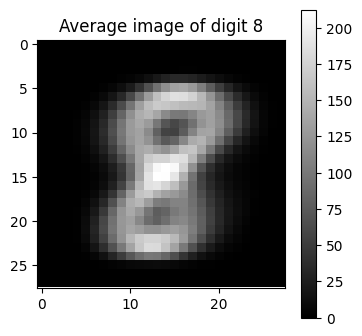

In [ ]:
# Gemiddelde pixelwaarde van alle afbeeldingen samen
average_pixel_value_all_traing = np.mean(x_train)
average_pixel_value_all_test = np.mean(x_test)

# Gemiddelde pixelwaarde van één specifiek cijfer
digit = 8

indices_training = np.where(y_train == digit)[0]
indices_test = np.where(y_test == digit)[0]

average_pixel_value_digit_training = np.mean(x_train[indices_training])
average_pixel_value_digit_test = np.mean(x_test[indices_test])


average_digit_image = np.mean(x_train[indices_training], axis=0)

# Vind lichste en donkerste pixels
lightest_pixel_value = np.max(average_digit_image)
darkest_pixel_value = np.min(average_digit_image)
lightest_pixel_position = np.unravel_index(np.argmax(average_digit_image), average_digit_image.shape)
darkest_pixel_position = np.unravel_index(np.argmin(average_digit_image), average_digit_image.shape)

print("Training set:")
print(f"Average pixel value of all images together: {average_pixel_value_all_traing}")
print(f"Average pixel value of {digit}: {average_pixel_value_digit_training}")

print()

print("Test set:")
print(f"Average pixel value of all images together: {average_pixel_value_all_test}")
print(f"Average pixel value of {digit}: {average_pixel_value_digit_test}")

print()

print(f"For digit {digit}:")
print(f"Lightest pixel: value {lightest_pixel_value:.2f} at position {lightest_pixel_position}")
print(f"Darkest pixel: value {darkest_pixel_value:.2f} at position {darkest_pixel_position}")

print()

# Visualiseer het gemiddelde beeld van het cijfer
plt.figure(figsize=(4, 4))
plt.imshow(average_digit_image, cmap='gray')
plt.title(f'Average image of digit {digit}')
plt.colorbar()
plt.show()


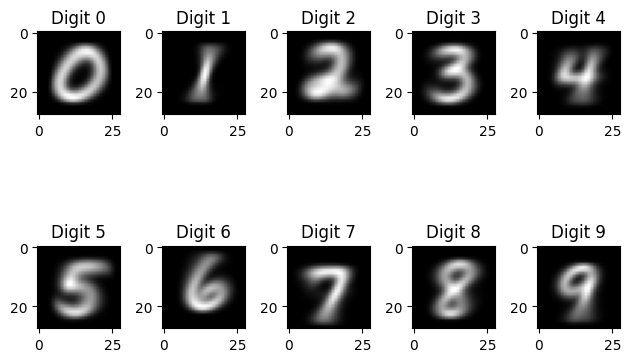

In [ ]:
fig, axs = plt.subplots(2, 5)

for i in range(10):
    average_digit_image = np.mean(x_train[np.where(y_train == i)[0]], axis=0)
    row, col = divmod(i, 5)
    axs[row, col].imshow(average_digit_image, cmap='gray')
    axs[row, col].set_title(f'Digit {i}')

plt.tight_layout()
plt.show()



from tensorflow.keras.datasets import mnist https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data
